<a href="https://colab.research.google.com/github/ggtorres/Deep-Learning/blob/main/%5BDL%5D_Projeto_Integrado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Final Integrado - Deep Learning

**Curso:** MBA Data Science & Artificial Intelligence

**Matéria:** Deep Learning

Trabalho Final Integrado

**Alunos:**

Guilherme Torres Guedes - RM: 363544

Johnny Mendes Alves - RM: 364028

Sabrina Terezinha Dresch da Silva - RM: 363519

## Bibliotecas e Parâmetros

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, GRU, LSTM, Bidirectional, BatchNormalization, GlobalAveragePooling1D, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Carregamento da Base

In [ ]:
# fixando seed
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
acoes_lista = ["vale3", "petr4", "bbas3", "csna3"]

data = {}

for acoes in acoes_lista:
    train_path = f"treino_{acoes}.csv"
    test_path  = f"teste_{acoes}.csv"

    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    data[acoes.upper()] = {
        "train": train_df,
        "test": test_df
    }

    print(f"\n===== {acoes.upper()} =====")
    print("Treino:", train_df.shape)
    print("Teste :", test_df.shape)


===== VALE3 =====
Treino: (4808, 20)
Teste : (1203, 20)

===== PETR4 =====
Treino: (4808, 20)
Teste : (1203, 20)

===== BBAS3 =====
Treino: (4735, 20)
Teste : (1185, 20)

===== CSNA3 =====
Treino: (4743, 20)
Teste : (1186, 20)


## Análise Exploratória



In [ ]:
for acoes in data:
    print(f"\nColunas de {acoes}:")
    print(data[acoes]["train"].columns.tolist())



Colunas de VALE3:
['Unnamed: 0', 'Date', 'Close', 'Smoothed_Close', 'Label', 'Past_1_Days_Close', 'Past_2_Days_Close', 'Past_3_Days_Close', 'Past_4_Days_Close', 'Past_5_Days_Close', 'Past_6_Days_Close', 'Past_7_Days_Close', 'Past_8_Days_Close', 'Past_9_Days_Close', 'Past_10_Days_Close', 'Past_11_Days_Close', 'Past_12_Days_Close', 'Past_13_Days_Close', 'Past_14_Days_Close', 'Past_15_Days_Close']

Colunas de PETR4:
['Unnamed: 0', 'Date', 'Close', 'Smoothed_Close', 'Label', 'Past_1_Days_Close', 'Past_2_Days_Close', 'Past_3_Days_Close', 'Past_4_Days_Close', 'Past_5_Days_Close', 'Past_6_Days_Close', 'Past_7_Days_Close', 'Past_8_Days_Close', 'Past_9_Days_Close', 'Past_10_Days_Close', 'Past_11_Days_Close', 'Past_12_Days_Close', 'Past_13_Days_Close', 'Past_14_Days_Close', 'Past_15_Days_Close']

Colunas de BBAS3:
['Unnamed: 0', 'Date', 'Close', 'Smoothed_Close', 'Label', 'Past_1_Days_Close', 'Past_2_Days_Close', 'Past_3_Days_Close', 'Past_4_Days_Close', 'Past_5_Days_Close', 'Past_6_Days_Close'

In [ ]:
data["VALE3"]["train"].head()

,Unnamed: 0,Date,Close,Smoothed_Close,Label,Past_1_Days_Close,Past_2_Days_Close,Past_3_Days_Close,Past_4_Days_Close,Past_5_Days_Close,Past_6_Days_Close,Past_7_Days_Close,Past_8_Days_Close,Past_9_Days_Close,Past_10_Days_Close,Past_11_Days_Close,Past_12_Days_Close,Past_13_Days_Close,Past_14_Days_Close,Past_15_Days_Close
0,1,2000-01-24,1.829122,1.752574,1,1.791015,1.829122,1.840554,1.848175,1.905335,1.867229,1.832933,1.773867,1.756719,1.752908,1.619535,1.562375,1.562375,1.562375,1.600482
1,2,2000-01-25,1.829122,1.760229,1,1.829122,1.791015,1.829122,1.840554,1.848175,1.905335,1.867229,1.832933,1.773867,1.756719,1.752908,1.619535,1.562375,1.562375,1.562375
2,3,2000-01-26,1.813879,1.765594,1,1.829122,1.829122,1.791015,1.829122,1.840554,1.848175,1.905335,1.867229,1.832933,1.773867,1.756719,1.752908,1.619535,1.562375,1.562375
3,4,2000-01-27,1.829122,1.771947,1,1.813879,1.829122,1.829122,1.791015,1.829122,1.840554,1.848175,1.905335,1.867229,1.832933,1.773867,1.756719,1.752908,1.619535,1.562375
4,5,2000-01-28,1.829122,1.777664,1,1.829122,1.813879,1.829122,1.829122,1.791015,1.829122,1.840554,1.848175,1.905335,1.867229,1.832933,1.773867,1.756719,1.752908,1.619535


In [ ]:
data["PETR4"]["train"].head()

,Unnamed: 0,Date,Close,Smoothed_Close,Label,Past_1_Days_Close,Past_2_Days_Close,Past_3_Days_Close,Past_4_Days_Close,Past_5_Days_Close,Past_6_Days_Close,Past_7_Days_Close,Past_8_Days_Close,Past_9_Days_Close,Past_10_Days_Close,Past_11_Days_Close,Past_12_Days_Close,Past_13_Days_Close,Past_14_Days_Close,Past_15_Days_Close
0,1,2000-01-24,1.274788,1.347845,-1,1.283923,1.311824,1.314787,1.324169,1.317996,1.333305,1.314787,1.353798,1.351823,1.385896,1.357995,1.351823,1.356514,1.370341,1.450586
1,2,2000-01-25,1.274788,1.340540,-1,1.274788,1.283923,1.311824,1.314787,1.324169,1.317996,1.333305,1.314787,1.353798,1.351823,1.385896,1.357995,1.351823,1.356514,1.370341
2,3,2000-01-26,1.290096,1.335495,-1,1.274788,1.274788,1.283923,1.311824,1.314787,1.324169,1.317996,1.333305,1.314787,1.353798,1.351823,1.385896,1.357995,1.351823,1.356514
3,4,2000-01-27,1.280960,1.330042,-1,1.290096,1.274788,1.274788,1.283923,1.311824,1.314787,1.324169,1.317996,1.333305,1.314787,1.353798,1.351823,1.385896,1.357995,1.351823
4,5,2000-01-28,1.280960,1.325134,-1,1.280960,1.290096,1.274788,1.274788,1.283923,1.311824,1.314787,1.324169,1.317996,1.333305,1.314787,1.353798,1.351823,1.385896,1.357995


In [ ]:
data["BBAS3"]["train"].head()

,Unnamed: 0,Date,Close,Smoothed_Close,Label,Past_1_Days_Close,Past_2_Days_Close,Past_3_Days_Close,Past_4_Days_Close,Past_5_Days_Close,Past_6_Days_Close,Past_7_Days_Close,Past_8_Days_Close,Past_9_Days_Close,Past_10_Days_Close,Past_11_Days_Close,Past_12_Days_Close,Past_13_Days_Close,Past_14_Days_Close,Past_15_Days_Close
0,1,2000-01-24,1.062769,1.071645,-1,1.088979,1.079805,1.086357,1.098152,1.069322,1.061459,1.062769,1.081116,1.066701,1.081116,1.024767,1.048355,1.033940,1.023457,1.074564
1,2,2000-01-26,1.087668,1.073247,-1,1.062769,1.088979,1.079805,1.086357,1.098152,1.069322,1.061459,1.062769,1.081116,1.066701,1.081116,1.024767,1.048355,1.033940,1.023457
2,3,2000-01-27,1.064080,1.072330,-1,1.087668,1.062769,1.088979,1.079805,1.086357,1.098152,1.069322,1.061459,1.062769,1.081116,1.066701,1.081116,1.024767,1.048355,1.033940
3,4,2000-01-28,1.036561,1.068753,-1,1.064080,1.087668,1.062769,1.088979,1.079805,1.086357,1.098152,1.069322,1.061459,1.062769,1.081116,1.066701,1.081116,1.024767,1.048355
4,5,2000-01-31,1.035250,1.065403,-1,1.036561,1.064080,1.087668,1.062769,1.088979,1.079805,1.086357,1.098152,1.069322,1.061459,1.062769,1.081116,1.066701,1.081116,1.024767


In [ ]:
data["CSNA3"]["train"].head()

,Unnamed: 0,Date,Close,Smoothed_Close,Label,Past_1_Days_Close,Past_2_Days_Close,Past_3_Days_Close,Past_4_Days_Close,Past_5_Days_Close,Past_6_Days_Close,Past_7_Days_Close,Past_8_Days_Close,Past_9_Days_Close,Past_10_Days_Close,Past_11_Days_Close,Past_12_Days_Close,Past_13_Days_Close,Past_14_Days_Close,Past_15_Days_Close
0,1,2000-01-24,1.409986,1.588954,-1,1.375888,1.478184,1.522513,1.566841,1.594120,1.500348,1.546381,1.704941,1.785073,1.863500,1.841336,1.853271,1.773139,1.682777,1.658908
1,2,2000-01-26,1.398052,1.569864,-1,1.409986,1.375888,1.478184,1.522513,1.566841,1.594120,1.500348,1.546381,1.704941,1.785073,1.863500,1.841336,1.853271,1.773139,1.682777
2,3,2000-01-27,1.375888,1.550466,-1,1.398052,1.409986,1.375888,1.478184,1.522513,1.566841,1.594120,1.500348,1.546381,1.704941,1.785073,1.863500,1.841336,1.853271,1.773139
3,4,2000-01-28,1.363953,1.531815,-1,1.375888,1.398052,1.409986,1.375888,1.478184,1.522513,1.566841,1.594120,1.500348,1.546381,1.704941,1.785073,1.863500,1.841336,1.853271
4,5,2000-01-31,1.329854,1.511619,-1,1.363953,1.375888,1.398052,1.409986,1.375888,1.478184,1.522513,1.566841,1.594120,1.500348,1.546381,1.704941,1.785073,1.863500,1.841336


In [ ]:
for acoes in data:
    print(f"\n{acoes} - Nulos no treino:")
    print(data[acoes]["train"].isnull().sum())

    print(f"\n{acoes} - Nulos no teste:")
    print(data[acoes]["test"].isnull().sum())



VALE3 - Nulos no treino:
Unnamed: 0            0
Date                  0
Close                 0
Smoothed_Close        0
Label                 0
Past_1_Days_Close     0
Past_2_Days_Close     0
Past_3_Days_Close     0
Past_4_Days_Close     0
Past_5_Days_Close     0
Past_6_Days_Close     0
Past_7_Days_Close     0
Past_8_Days_Close     0
Past_9_Days_Close     0
Past_10_Days_Close    0
Past_11_Days_Close    0
Past_12_Days_Close    0
Past_13_Days_Close    0
Past_14_Days_Close    0
Past_15_Days_Close    0
dtype: int64

VALE3 - Nulos no teste:
Unnamed: 0            0
Date                  0
Close                 0
Smoothed_Close        0
Label                 0
Past_1_Days_Close     0
Past_2_Days_Close     0
Past_3_Days_Close     0
Past_4_Days_Close     0
Past_5_Days_Close     0
Past_6_Days_Close     0
Past_7_Days_Close     0
Past_8_Days_Close     0
Past_9_Days_Close     0
Past_10_Days_Close    0
Past_11_Days_Close    0
Past_12_Days_Close    0
Past_13_Days_Close    0
Past_14_Days_Close    0


## Limpeza


In [ ]:
# excluíndo coluna de índice
def basic_clean(df):
    df = df.copy()
    df = df.drop(columns=["Unnamed: 0"])
    return df

In [ ]:
for acoes in data:
    data[acoes]["train"] = basic_clean(data[acoes]["train"])
    data[acoes]["test"]  = basic_clean(data[acoes]["test"])

## Separar Bases

In [ ]:
colunas_desconsiderar = [
    "Close",
    "Smoothed_Close",
    "Label",
    "Date"
]

In [ ]:
processed = {}

for acoes in data:
    train_df = data[acoes]["train"].copy()
    test_df  = data[acoes]["test"].copy()

    features = [c for c in train_df.columns if c not in colunas_desconsiderar]

    X_train = train_df[features].values
    y_train = train_df["Label"].values

    X_test = test_df[features].values
    y_test = test_df["Label"].values

    processed[acoes] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "features": features
    }

    print(f"\n{acoes}")
    print("Features usadas:", features)
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)



VALE3
Features usadas: ['Past_1_Days_Close', 'Past_2_Days_Close', 'Past_3_Days_Close', 'Past_4_Days_Close', 'Past_5_Days_Close', 'Past_6_Days_Close', 'Past_7_Days_Close', 'Past_8_Days_Close', 'Past_9_Days_Close', 'Past_10_Days_Close', 'Past_11_Days_Close', 'Past_12_Days_Close', 'Past_13_Days_Close', 'Past_14_Days_Close', 'Past_15_Days_Close']
X_train: (4808, 15)
X_test : (1203, 15)

PETR4
Features usadas: ['Past_1_Days_Close', 'Past_2_Days_Close', 'Past_3_Days_Close', 'Past_4_Days_Close', 'Past_5_Days_Close', 'Past_6_Days_Close', 'Past_7_Days_Close', 'Past_8_Days_Close', 'Past_9_Days_Close', 'Past_10_Days_Close', 'Past_11_Days_Close', 'Past_12_Days_Close', 'Past_13_Days_Close', 'Past_14_Days_Close', 'Past_15_Days_Close']
X_train: (4808, 15)
X_test : (1203, 15)

BBAS3
Features usadas: ['Past_1_Days_Close', 'Past_2_Days_Close', 'Past_3_Days_Close', 'Past_4_Days_Close', 'Past_5_Days_Close', 'Past_6_Days_Close', 'Past_7_Days_Close', 'Past_8_Days_Close', 'Past_9_Days_Close', 'Past_10_Days_

In [ ]:
# função para retirar neutros
def fix_labels(X, y):
    mask = y != 0
    X = X[mask]
    y = y[mask]

    y = (y == 1).astype(int)

    return X, y

In [ ]:
# retirando neutros
for acoes in processed:
    X_train = processed[acoes]["X_train"]
    y_train = processed[acoes]["y_train"]

    X_test  = processed[acoes]["X_test"]
    y_test  = processed[acoes]["y_test"]

    X_train, y_train = fix_labels(X_train, y_train)
    X_test,  y_test  = fix_labels(X_test,  y_test)

    processed[acoes]["X_train"] = X_train
    processed[acoes]["y_train"] = y_train
    processed[acoes]["X_test"]  = X_test
    processed[acoes]["y_test"]  = y_test

    print(f"\n{acoes}")
    print("Classes treino:", np.unique(y_train))
    print("Classes teste :", np.unique(y_test))
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)



VALE3
Classes treino: [0 1]
Classes teste : [0 1]
X_train: (4808, 15)
X_test : (1203, 15)

PETR4
Classes treino: [0 1]
Classes teste : [0 1]
X_train: (4808, 15)
X_test : (1203, 15)

BBAS3
Classes treino: [0 1]
Classes teste : [0 1]
X_train: (4735, 15)
X_test : (1185, 15)

CSNA3
Classes treino: [0 1]
Classes teste : [0 1]
X_train: (4743, 15)
X_test : (1186, 15)


## Normalização

In [ ]:
scalers = {}

for acoes in processed:
    scaler = StandardScaler()

    X_train = processed[acoes]["X_train"]
    X_test  = processed[acoes]["X_test"]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    processed[acoes]["X_train"] = X_train_scaled
    processed[acoes]["X_test"]  = X_test_scaled
    scalers[acoes] = scaler

    print(f"\n{acoes}")
    print("X_train norm:", X_train_scaled.shape)
    print("X_test  norm:", X_test_scaled.shape)


VALE3
X_train norm: (4808, 15)
X_test  norm: (1203, 15)

PETR4
X_train norm: (4808, 15)
X_test  norm: (1203, 15)

BBAS3
X_train norm: (4735, 15)
X_test  norm: (1185, 15)

CSNA3
X_train norm: (4743, 15)
X_test  norm: (1186, 15)


## Reshape

In [ ]:
for acoes in processed:
    X_train = processed[acoes]["X_train"]
    X_test  = processed[acoes]["X_test"]

    X_train = X_train.reshape(X_train.shape[0], 15, 1)
    X_test  = X_test.reshape(X_test.shape[0], 15, 1)

    processed[acoes]["X_train"] = X_train
    processed[acoes]["X_test"]  = X_test

    print(f"\n{acoes}")
    print("X_train DL:", X_train.shape)
    print("X_test  DL:", X_test.shape)



VALE3
X_train DL: (4808, 15, 1)
X_test  DL: (1203, 15, 1)

PETR4
X_train DL: (4808, 15, 1)
X_test  DL: (1203, 15, 1)

BBAS3
X_train DL: (4735, 15, 1)
X_test  DL: (1185, 15, 1)

CSNA3
X_train DL: (4743, 15, 1)
X_test  DL: (1186, 15, 1)


## CNN 1D

In [ ]:
def build_cnn_model(input_shape):

    model = Sequential([
        Input(shape=input_shape),

        Conv1D(64, kernel_size=3, activation="relu",
               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        MaxPooling1D(pool_size=2),

        Conv1D(32, kernel_size=3, activation="relu"),
        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
def train_and_evaluate_cnn_no_bt(acoes, processed, epochs=50):

    X_train = processed[acoes]["X_train"]
    y_train = processed[acoes]["y_train"]
    X_test  = processed[acoes]["X_test"]
    y_test  = processed[acoes]["y_test"]

    model = build_cnn_model(input_shape=(15, 1))

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=0
    )

    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    class_weights = dict(zip(classes, weights))

    print(f"\nIniciando treino para: {acoes}")
    print(f"Class weights: {class_weights}")

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.2,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_prob = model.predict(X_test)

    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)
    rep = classification_report(y_test, y_pred)

    print(f"\n===== RESULTADOS: {acoes} =====")
    print("Acurácia final:", acc)
    print("\nMatriz de Confusão:\n", cm)
    print("\nRelatório de Classificação:\n", rep)

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="Treino (Acc)")
    plt.plot(history.history["val_accuracy"], label="Validação (Acc)")
    plt.title(f"Curva de Aprendizado - {acoes}")
    plt.xlabel("Épocas")
    plt.ylabel("Acurácia")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return {
        "model": model,
        "history": history,
        "acc": acc,
        "cm": cm,
        "report": rep,
        "y_pred": y_pred
    }


Iniciando treino para: VALE3
Class weights: {np.int64(0): np.float64(0.8851251840942562), np.int64(1): np.float64(1.1491395793499044)}
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== RESULTADOS: VALE3 =====
Acurácia final: 0.7921862011637573

Matriz de Confusão:
 [[355 246]
 [  4 598]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.99      0.59      0.74       601
           1       0.71      0.99      0.83       602

    accuracy                           0.79      1203
   macro avg       0.85      0.79      0.78      1203
weighted avg       0.85      0.79      0.78      1203



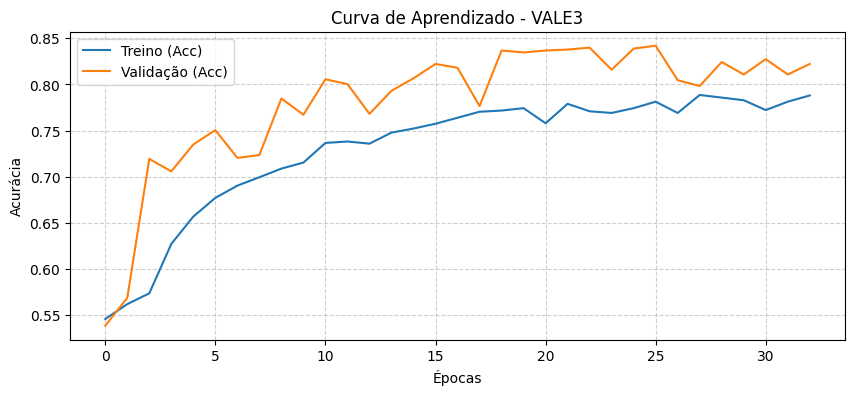


Iniciando treino para: PETR4
Class weights: {np.int64(0): np.float64(0.905802562170309), np.int64(1): np.float64(1.116063138347261)}
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== RESULTADOS: PETR4 =====
Acurácia final: 0.8420615128844555

Matriz de Confusão:
 [[462 119]
 [ 71 551]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83       581
           1       0.82      0.89      0.85       622

    accuracy                           0.84      1203
   macro avg       0.84      0.84      0.84      1203
weighted avg       0.84      0.84      0.84      1203



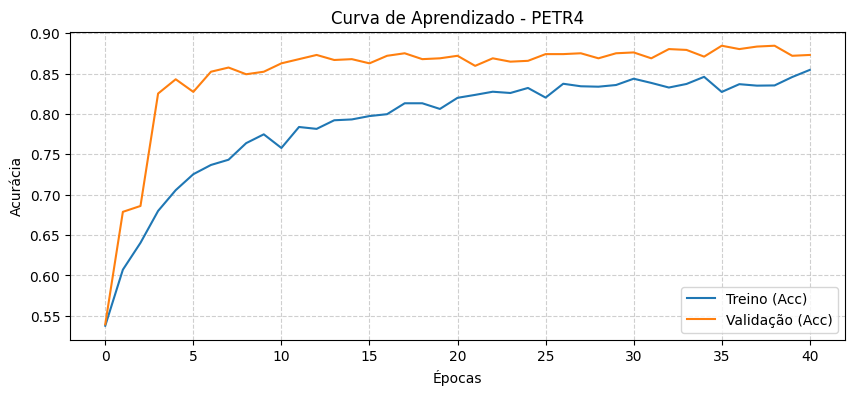


Iniciando treino para: BBAS3
Class weights: {np.int64(0): np.float64(0.9098770176787087), np.int64(1): np.float64(1.1099390529770277)}
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== RESULTADOS: BBAS3 =====
Acurácia final: 0.6742616033755274

Matriz de Confusão:
 [[673  16]
 [370 126]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.65      0.98      0.78       689
           1       0.89      0.25      0.39       496

    accuracy                           0.67      1185
   macro avg       0.77      0.62      0.59      1185
weighted avg       0.75      0.67      0.62      1185



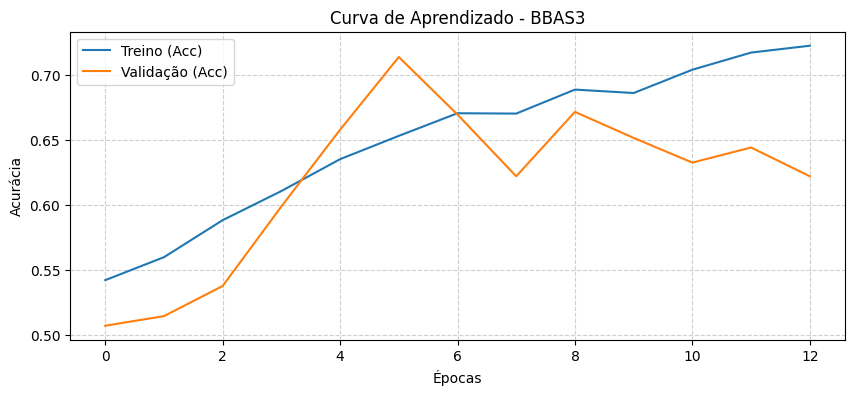


Iniciando treino para: CSNA3
Class weights: {np.int64(0): np.float64(0.8932203389830509), np.int64(1): np.float64(1.1357758620689655)}
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== RESULTADOS: CSNA3 =====
Acurácia final: 0.7824620573355818

Matriz de Confusão:
 [[449 239]
 [ 19 479]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.96      0.65      0.78       688
           1       0.67      0.96      0.79       498

    accuracy                           0.78      1186
   macro avg       0.81      0.81      0.78      1186
weighted avg       0.84      0.78      0.78      1186



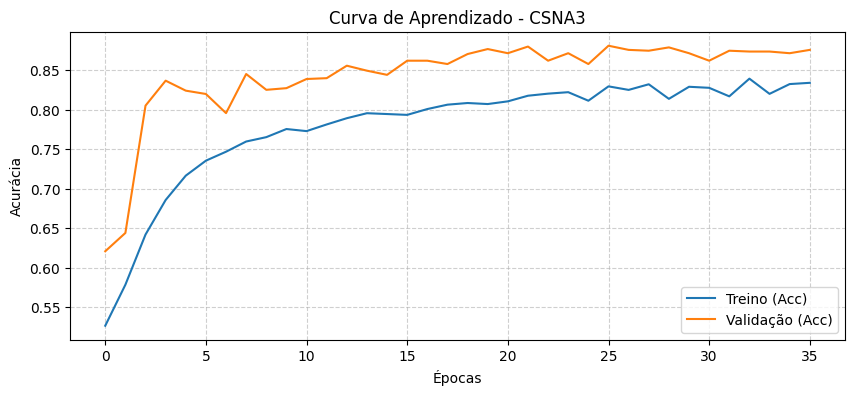

In [ ]:
results = {}
for acoes in processed:
    results[acoes] = train_and_evaluate_cnn_no_bt(
        acoes=acoes,
        processed=processed,
        epochs=50
    )

In [ ]:
summary_cnn = []

for acoes in results:
    acc = results[acoes]["acc"]

    report = classification_report(
        processed[acoes]["y_test"],
        results[acoes]["y_pred"],
        output_dict=True
    )

    summary_cnn.append({
        "Ativo": acoes,
        "Acurácia": acc,
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"]
    })

summary_cnn_df = pd.DataFrame(summary_cnn)
summary_cnn_df

,Ativo,Acurácia,Precision_0,Recall_0,Precision_1,Recall_1
0,VALE3,0.792186,0.988858,0.590682,0.708531,0.993355
1,PETR4,0.842062,0.866792,0.795181,0.822388,0.885852
2,BBAS3,0.674262,0.645254,0.976778,0.887324,0.254032
3,CSNA3,0.782462,0.959402,0.652616,0.667131,0.961847


In [ ]:
def backtest(prices, y_pred):
    returns = []
    position = 0

    for i in range(len(y_pred) - 1):
        if y_pred[i] == 1:
            position = 1
        else:
            position = -1

        ret = position * (prices[i+1] - prices[i]) / prices[i]
        returns.append(ret)

    return np.sum(returns)

In [ ]:
for acoes in results:
    prices_full = data[acoes]["test"]["Close"].values
    y_test_full = data[acoes]["test"]["Label"].values

    mask = y_test_full != 0
    prices = prices_full[mask]

    y_pred = results[acoes]["y_pred"]

    cum_return = backtest(prices, y_pred)

    print(f"\n===== {acoes} =====")
    print("Retorno acumulado:", cum_return)
    print("Retorno %:", cum_return * 100, "%")

    results[acoes]["cum_return"] = cum_return


===== VALE3 =====
Retorno acumulado: 0.7180993979882905
Retorno %: 71.80993979882905 %

===== PETR4 =====
Retorno acumulado: 0.44591347913986007
Retorno %: 44.591347913986006 %

===== BBAS3 =====
Retorno acumulado: -0.3231983042973863
Retorno %: -32.31983042973863 %

===== CSNA3 =====
Retorno acumulado: 1.5753932734415552
Retorno %: 157.5393273441555 %


## RNN

In [ ]:
def create_sequences(X, y, time_steps=15):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:(i + time_steps)])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

def add_features(df):
    df = df.copy()
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))
    return df.fillna(0)

processed_rnn = {}
n_steps = 15

for acao in data:
    train_df = add_features(data[acao]["train"])
    test_df  = add_features(data[acao]["test"])

    features = [c for c in train_df.columns if c not in colunas_desconsiderar]

    X_train_raw, y_train_raw = fix_labels(train_df[features].values, train_df["Label"].values)
    X_test_raw, y_test_raw   = fix_labels(test_df[features].values, test_df["Label"].values)

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    X_train_rnn, y_train_rnn = create_sequences(X_train_scaled, y_train_raw, n_steps)
    X_test_rnn, y_test_rnn   = create_sequences(X_test_scaled, y_test_raw, n_steps)

    processed_rnn[acao] = {
        "X_train": X_train_rnn, "y_train": y_train_rnn,
        "X_test": X_test_rnn, "y_test": y_test_rnn,
        "input_shape": (n_steps, X_train_scaled.shape[1])
    }

In [ ]:
def build_rnn_final_boss(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GaussianNoise(0.01),
        Bidirectional(GRU(128, return_sequences=True)),
        BatchNormalization(),
        Bidirectional(GRU(64, return_sequences=True)),
        Dropout(0.3),
        GlobalAveragePooling1D(),
        Dense(64, activation="elu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=1000, decay_rate=0.9
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="binary_crossentropy", metrics=["accuracy"]
    )
    return model


Iniciando treino para: VALE3 ---
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

===== RESULTADOS: VALE3 =====
Acurácia final: 0.8686868686868687

Matriz de Confusão:
 [[486 115]
 [ 41 546]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86       601
           1       0.83      0.93      0.88       587

    accuracy                           0.87      1188
   macro avg       0.87      0.87      0.87      1188
weighted avg       0.87      0.87      0.87      1188



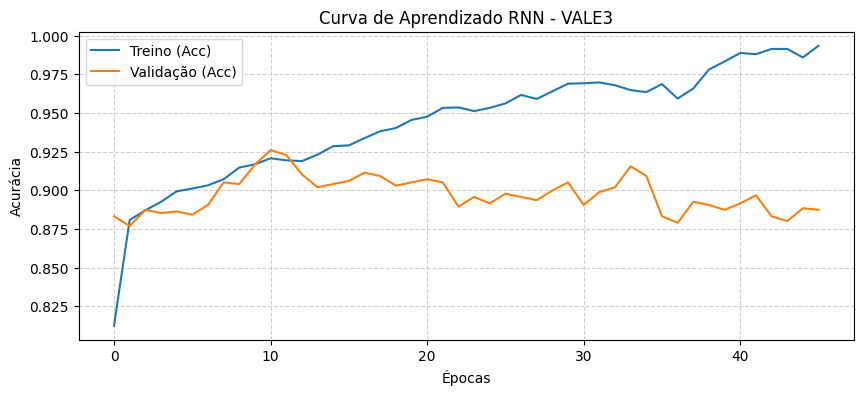


Iniciando treino para: PETR4 ---
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

===== RESULTADOS: PETR4 =====
Acurácia final: 0.8358585858585859

Matriz de Confusão:
 [[540  41]
 [154 453]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.78      0.93      0.85       581
           1       0.92      0.75      0.82       607

    accuracy                           0.84      1188
   macro avg       0.85      0.84      0.83      1188
weighted avg       0.85      0.84      0.83      1188



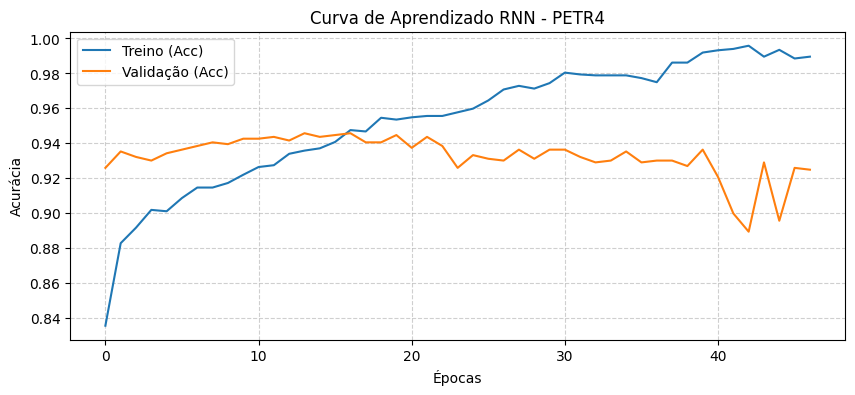


Iniciando treino para: BBAS3 ---
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

===== RESULTADOS: BBAS3 =====
Acurácia final: 0.8538461538461538

Matriz de Confusão:
 [[563 111]
 [ 60 436]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87       674
           1       0.80      0.88      0.84       496

    accuracy                           0.85      1170
   macro avg       0.85      0.86      0.85      1170
weighted avg       0.86      0.85      0.85      1170



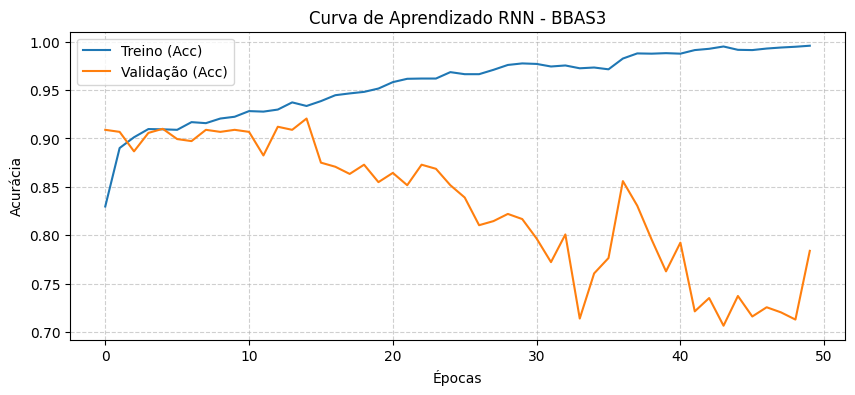


Iniciando treino para: CSNA3 ---
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

===== RESULTADOS: CSNA3 =====
Acurácia final: 0.8659265584970111

Matriz de Confusão:
 [[574 112]
 [ 45 440]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.93      0.84      0.88       686
           1       0.80      0.91      0.85       485

    accuracy                           0.87      1171
   macro avg       0.86      0.87      0.86      1171
weighted avg       0.87      0.87      0.87      1171



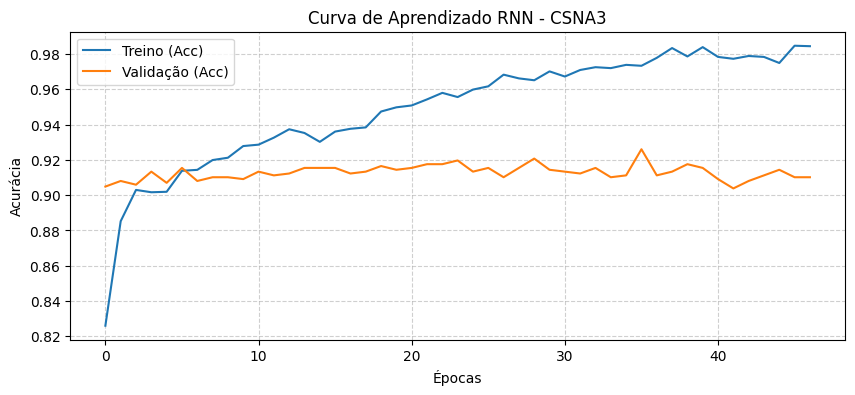

In [ ]:
results_rnn = {}
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=35, restore_best_weights=True
)

for acao in processed_rnn:
    print(f"\nIniciando treino para: {acao} ---")

    X_train, y_train = processed_rnn[acao]["X_train"], processed_rnn[acao]["y_train"]
    X_test, y_test   = processed_rnn[acao]["X_test"], processed_rnn[acao]["y_test"]

    model = build_rnn_final_boss(processed_rnn[acao]["input_shape"])

    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=64,
        validation_split=0.2,
        class_weight={0: 1.1, 1: 1.0},
        callbacks=[early_stop],
        shuffle=True,
        verbose=0
    )

    y_pred_prob = model.predict(X_test)

    best_acc, best_thr = 0, 0.5
    for thr in np.arange(0.40, 0.65, 0.01):
        y_temp = (y_pred_prob > thr).astype(int)
        acc_temp = accuracy_score(y_test, y_temp)
        if acc_temp > best_acc:
            best_acc, best_thr = acc_temp, thr

    y_pred = (y_pred_prob > best_thr).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)
    rep = classification_report(y_test, y_pred)

    print(f"\n===== RESULTADOS: {acao} =====")
    print("Acurácia final:", acc)
    print("\nMatriz de Confusão:\n", cm)
    print("\nRelatório de Classificação:\n", rep)

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="Treino (Acc)")
    plt.plot(history.history["val_accuracy"], label="Validação (Acc)")
    plt.title(f"Curva de Aprendizado RNN - {acao}")
    plt.xlabel("Épocas")
    plt.ylabel("Acurácia")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    results_rnn[acao] = {
        "model": model,
        "history": history,
        "acc": acc,
        "cm": cm,
        "report": rep,
        "y_pred": y_pred,
        "best_thr": best_thr
    }

In [ ]:
summary_rnn = []

for acao in results_rnn:
    acc = results_rnn[acao]["acc"]

    report = classification_report(
        processed_rnn[acao]["y_test"],
        results_rnn[acao]["y_pred"],
        output_dict=True
    )

    summary_rnn.append({
        "Ativo": acao,
        "Acurácia": acc,
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"]
    })

summary_rnn_df = pd.DataFrame(summary_rnn)
summary_rnn_df

,Ativo,Acurácia,Precision_0,Recall_0,Precision_1,Recall_1
0,VALE3,0.868687,0.922201,0.808652,0.826021,0.930153
1,PETR4,0.835859,0.778098,0.929432,0.917004,0.746293
2,BBAS3,0.853846,0.903692,0.835312,0.797075,0.879032
3,CSNA3,0.865927,0.927302,0.836735,0.797101,0.907216


In [ ]:
def backtest(prices, y_pred):
    returns = []
    position = 0

    for i in range(len(y_pred) - 1):
        if y_pred[i] == 1:
            position = 1
        else:
            position = -1

        ret = position * (prices[i+1] - prices[i]) / prices[i]
        returns.append(ret)

    return np.sum(returns)

In [ ]:
for acao in results_rnn:
    prices_full = data[acao]["test"]["Close"].values
    y_test_full = data[acao]["test"]["Label"].values

    mask = y_test_full != 0
    prices = prices_full[mask]

    y_pred = results_rnn[acao]["y_pred"]

    cum_return = backtest(prices, y_pred)

    print(f"\n===== {acao} =====")
    print("Retorno acumulado:", cum_return)
    print("Retorno %:", cum_return * 100, "%")

    results_rnn[acao]["cum_return"] = cum_return


===== VALE3 =====
Retorno acumulado: 3.705414483996693
Retorno %: 370.5414483996693 %

===== PETR4 =====
Retorno acumulado: 3.7052902391843956
Retorno %: 370.5290239184396 %

===== BBAS3 =====
Retorno acumulado: 1.3847054789208975
Retorno %: 138.47054789208974 %

===== CSNA3 =====
Retorno acumulado: 4.117641560409681
Retorno %: 411.76415604096815 %
